In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
sns.set(style="whitegrid")
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

##  From Ornstein–Uhlenbeck Process in Statistical Physics to Vasicek Model

We start from the Langevin equation describing the velocity v(t) of a Brownian particle under the influence of a frictional force and random noise:

$$\frac{d v(t)}{dt} = -\gamma v(t) + \eta(t)$$

or in differential form:

$$d v = -\gamma v \, dt + \sigma \, dW_t$$

where:
- $v(t)$ is the velocity of a Brownian particle.
- $\gamma > 0$ is the friction coefficient (also called the damping rate or drag coefficient).
- $\eta(t)$ is a random force (often modeled as Gaussian white noise).
- $\sigma$ is the noise amplitude, controlling the strength of stochastic fluctuations.
- $W_t$ is a Wiener process (Brownian motion), meaning \eta(t) is usually taken as Gaussian white noise with properties:
  
  $$\langle \eta(t) \rangle = 0, \quad \langle \eta(t) \eta(t{\prime}) \rangle = 2D \delta(t - t{\prime})$$
  
where D is the diffusion coefficient and $\delta(t - t{\prime})$ is the Dirac delta function.

Note: The equation for a Brownian particle in a fluid with friction was originally introduced by Paul Langevin (1908) to describe Brownian motion under damping. Ornstein and Uhlenbeck (1930) solved this equation explicitly and analyzed its properties.

Solving for v(t):

$$ v(t) = v_0 e^{-\gamma t} + \int_0^t e^{-\gamma (t - s)} \eta(s) ds$$

and mean a variance can be calculated analytically.

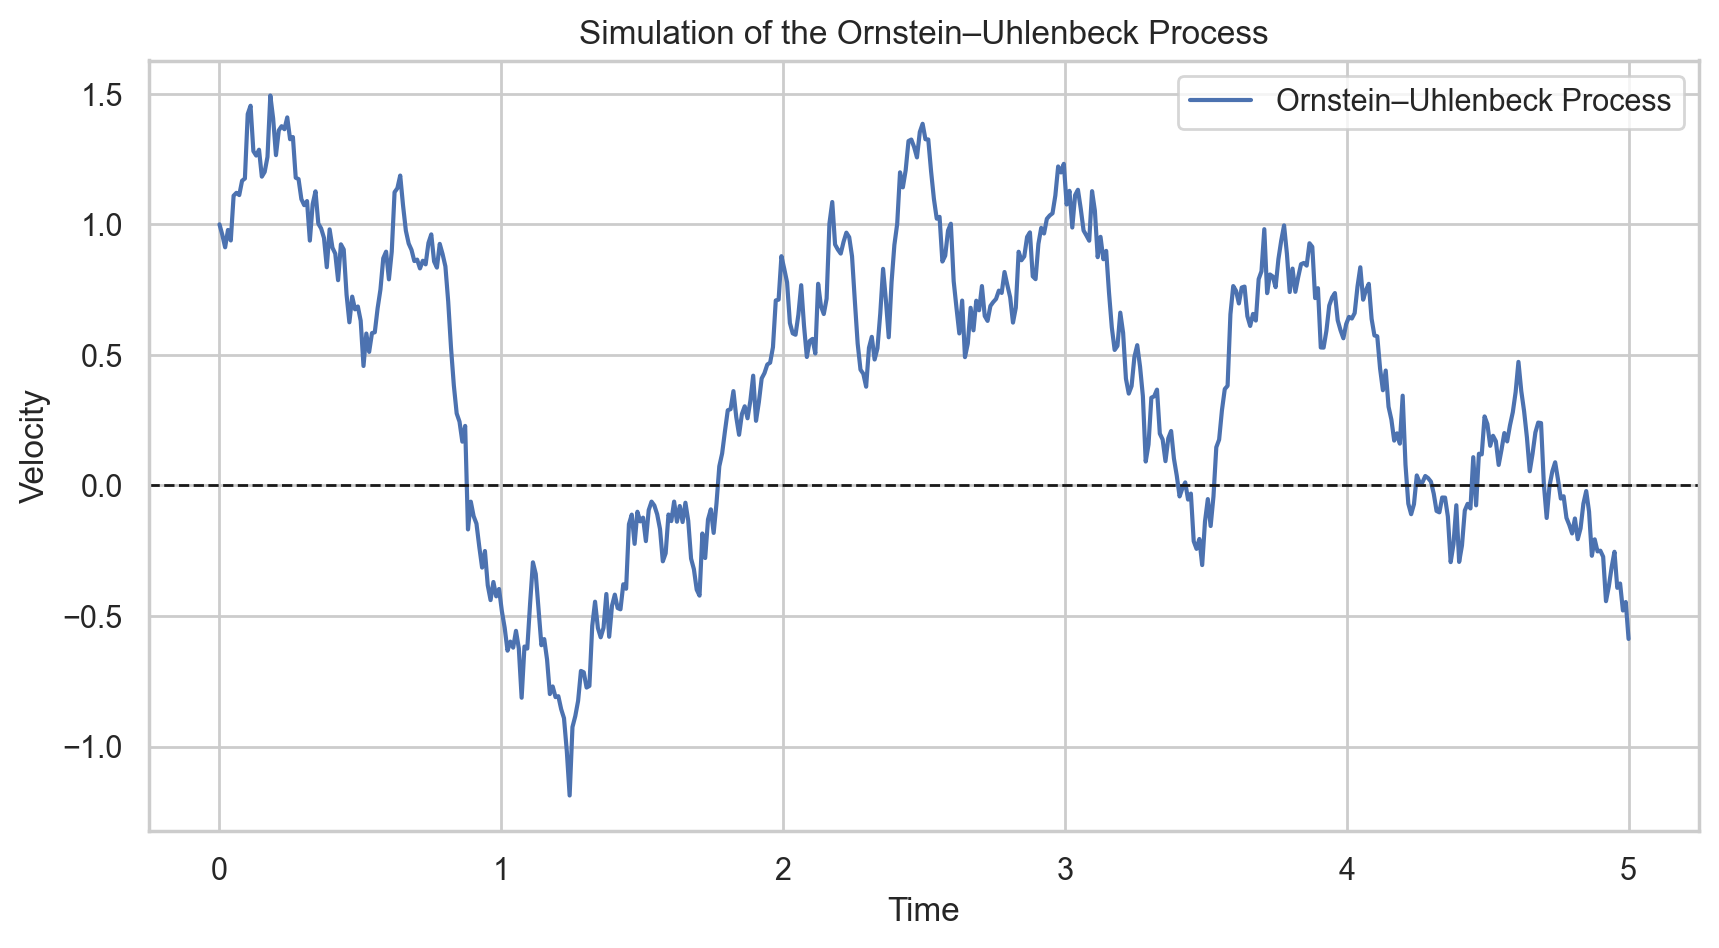

In [6]:
# Parameters
gamma = 1.0   # Mean-reversion speed
sigma = 1.0   # Noise intensity
v0 = 1.0      # Initial velocity
dt = 0.01     # Time step
T = 5.0       # Total time
N = int(T / dt)  # Number of time steps

# Time array
t = np.linspace(0, T, N)

# Initialize velocity array
v = np.zeros(N)
v[0] = v0

# Generate random noise (Brownian motion increments)
dW = np.sqrt(dt) * np.random.randn(N)

# Euler-Maruyama method for solving the SDE
for i in range(1, N):
    v[i] = v[i-1] - gamma * v[i-1] * dt + sigma * dW[i]

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t, v, label="Ornstein–Uhlenbeck Process")
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.title("Simulation of the Ornstein–Uhlenbeck Process")
plt.legend()
plt.show()


## Vasicek Interest Rate Model (Direct Application of OU Process)

The Vasicek model for the instataneous interest rate is definited by the following stochastic equation:

$$dr_t = \theta (\mu - r_t) dt + \sigma dW_t$$
where:
- $r_t$ is the interest rate (analogous to velocity v).
- $\theta$ controls how quickly rates revert to the long term $\mu$ (similar to $\gamma$ in physics).
- $\sigma$ represents rate volatility

### Expectation and variance

In [11]:
x0 = 2.0
theta = 1.0
mu = 3.0
sigma = 0.5
t= 10
s = 5

exp = x0*np.exp(-1.0*theta*t) +  mu*(1.0 - np.exp(-1.0*theta*t))
var = sigma**2/(2.0*theta)*(1 - np.exp(-2.0*theta*t)) 
cov = sigma**2/(2.0*theta)*np.exp(-1.0*(t+s))*(np.exp(2.0*theta*(np.min([t,s]))) - 1.0) 

print(f'For x_0={x0}' , f'theta={theta}',f'mu={mu}', f'sigma=.{sigma}', f't={t}', f's={s}', sep=", ")
print(f'E[X_t]= {exp: .6f}')
print(f'Var[X_t]={var :.2f}')
print(f'Cov[X_t, X_s]={cov :.6f}')

For x_0=2.0, theta=1.0, mu=3.0, sigma=.0.5, t=10, s=5
E[X_t]=  2.999955
Var[X_t]=0.12
Cov[X_t, X_s]=0.000842


### Marginal distribution

In [13]:
from scipy.stats import norm

x0 = 2.0 
theta = 1.0
mu = 3.0
sigma = 0.5
t =10

X_1 = norm(loc=(x0*np.exp(-1.0*theta*t)  + mu*(1.0 - np.exp(-1.0*theta*t))), 
           scale= np.sqrt( (sigma**2/(2.0*theta)*(1 - np.exp(-2.0*theta*t)) )) )

# Now we can calculate the mean and the variance of X_1
print(X_1.mean()) 
print(X_1.var())

2.9999546000702373
0.12499999974235582


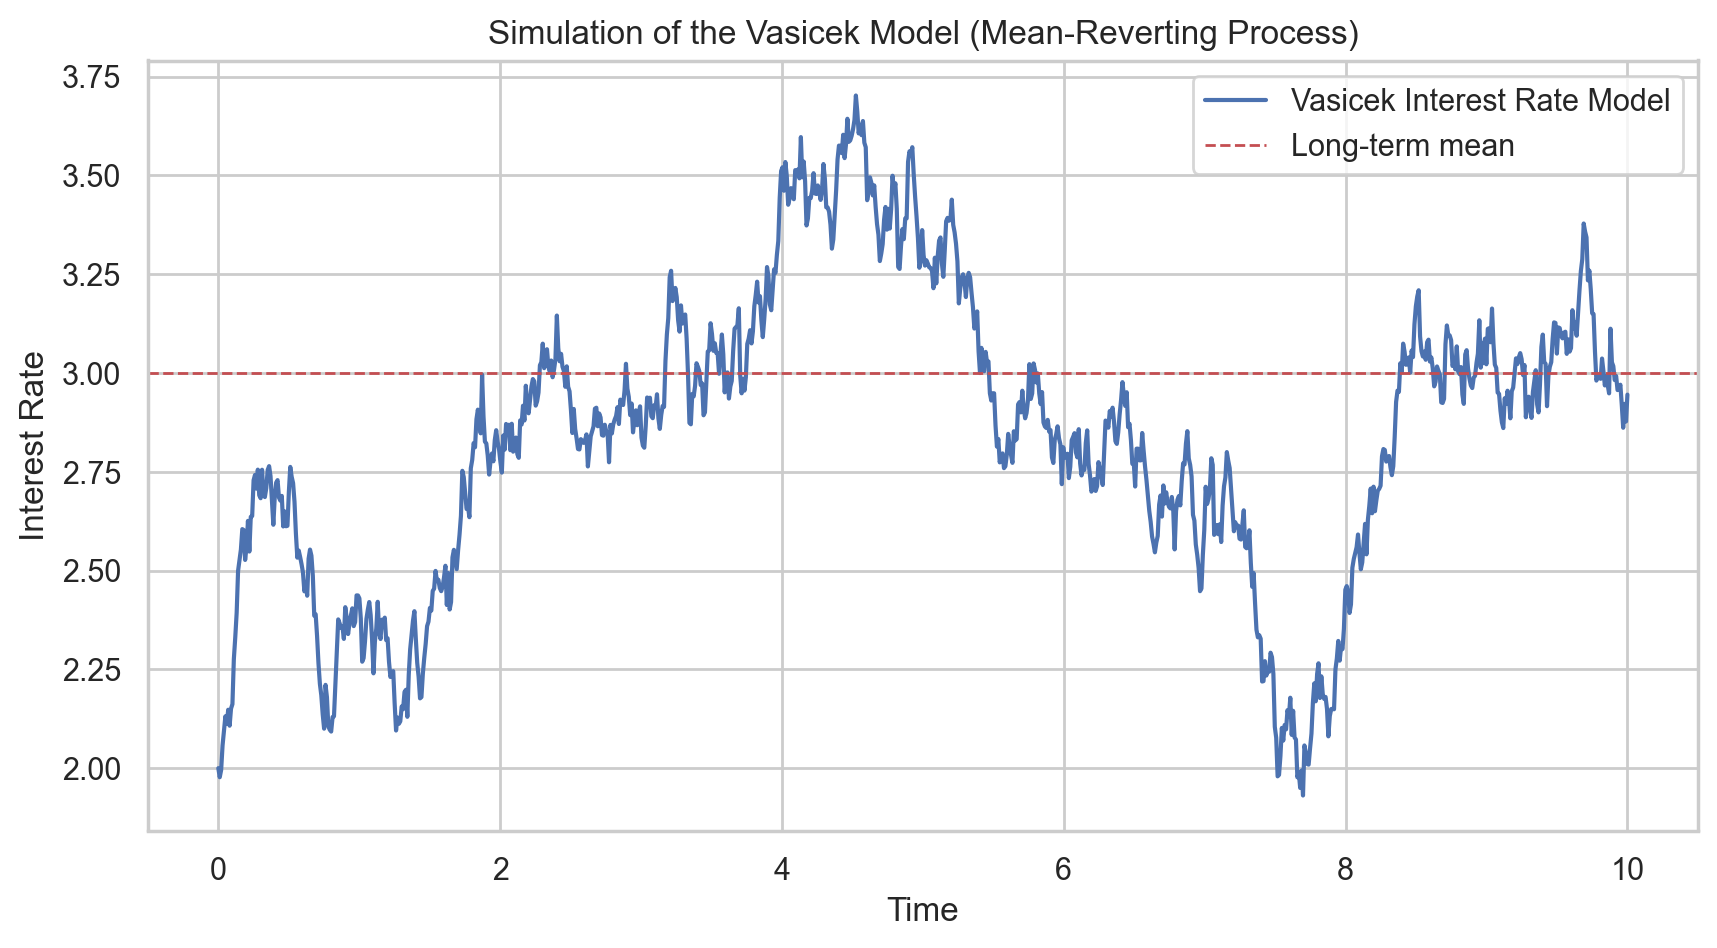

In [14]:
# Parameters for the Vasicek Model

theta = 1.0   # Mean-reversion speed
mu = 3.0    # Long-term mean interest rate
sigma = 0.5  # Volatility
r0 = 2.0     # Initial interest rate
dt = 0.01     # Time step
T = 10       # Total time
N = int(T / dt)  # Number of time steps

# Time array
t = np.linspace(0, T, N)

# Initialize interest rate array
r = np.zeros(N)
r[0] = r0

# Generate random noise (Brownian motion increments)
dW = np.sqrt(dt) * np.random.randn(N)

# Euler-Maruyama method for solving the Vasicek SDE
for i in range(1, N):
    r[i] = r[i-1] + theta * (mu - r[i-1]) * dt + sigma * dW[i]

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t, r, label="Vasicek Interest Rate Model")
plt.axhline(mu, color='r', linestyle='--', linewidth=1, label="Long-term mean")
plt.xlabel("Time")
plt.ylabel("Interest Rate")
plt.title("Simulation of the Vasicek Model (Mean-Reverting Process)")
plt.legend()
plt.show()


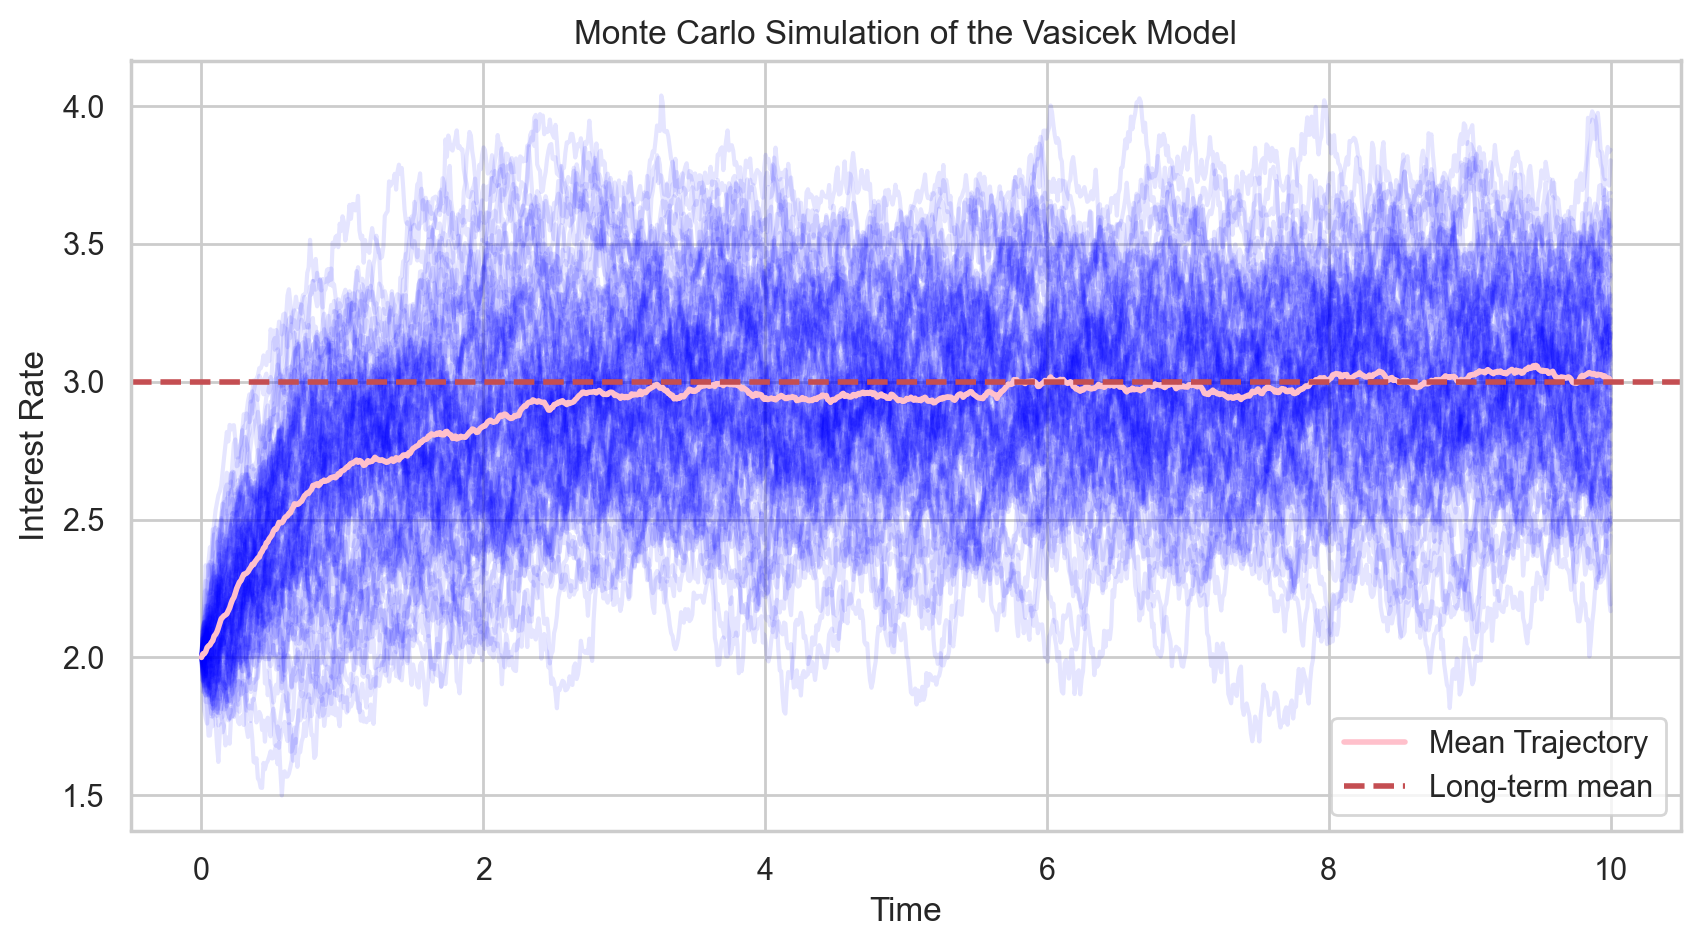

In [15]:
# Parameters for the Vasicek Model
theta = 1.0   # Mean-reversion speed
mu = 3.0    # Long-term mean interest rate
sigma = 0.5  # Volatility
r0 = 2.0     # Initial interest rate
dt = 0.01     # Time step
T = 10.0       # Total time
N = int(T / dt)  # Number of time steps
M = 100  # Number of Monte Carlo simulations

# Time array
t = np.linspace(0, T, N)

# Initialize interest rate array for all simulations
r = np.zeros((M, N))
r[:, 0] = r0

# Generate random noise for all simulations
dW = np.sqrt(dt) * np.random.randn(M, N)

# Euler-Maruyama method for solving the Vasicek SDE
for i in range(1, N):
    r[:, i] = r[:, i-1] + theta * (mu - r[:, i-1]) * dt + sigma * dW[:, i]

# Compute the mean trajectory
mean_r = np.mean(r, axis=0)

# Plot the results
plt.figure(figsize=(10, 5))
for i in range(M):
    plt.plot(t, r[i, :], color='blue', alpha=0.1)
plt.plot(t, mean_r, color='pink', linewidth=2, label="Mean Trajectory")
plt.axhline(mu, color='r', linestyle='--', linewidth=2, label="Long-term mean")
plt.xlabel("Time")
plt.ylabel("Interest Rate")
plt.title("Monte Carlo Simulation of the Vasicek Model")
plt.legend()
plt.show()


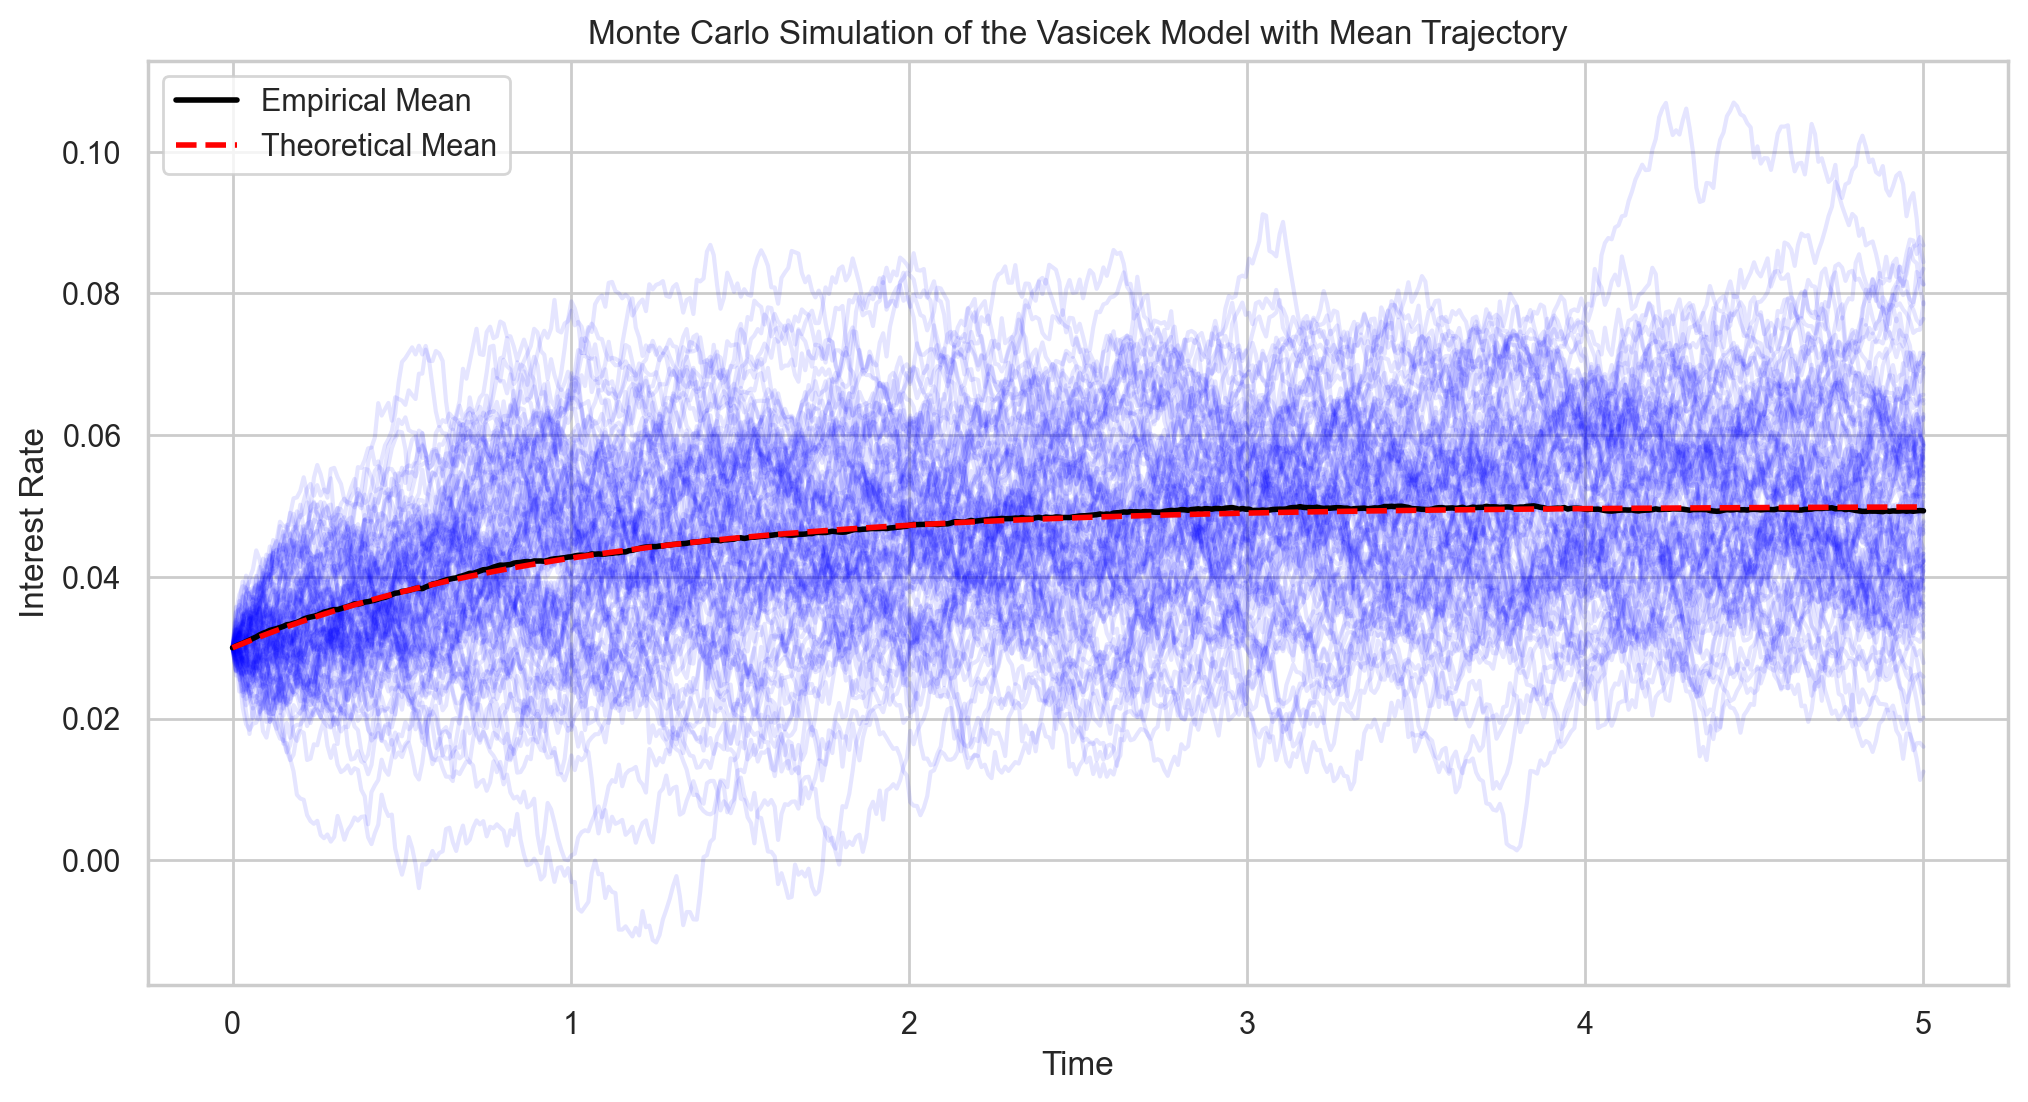

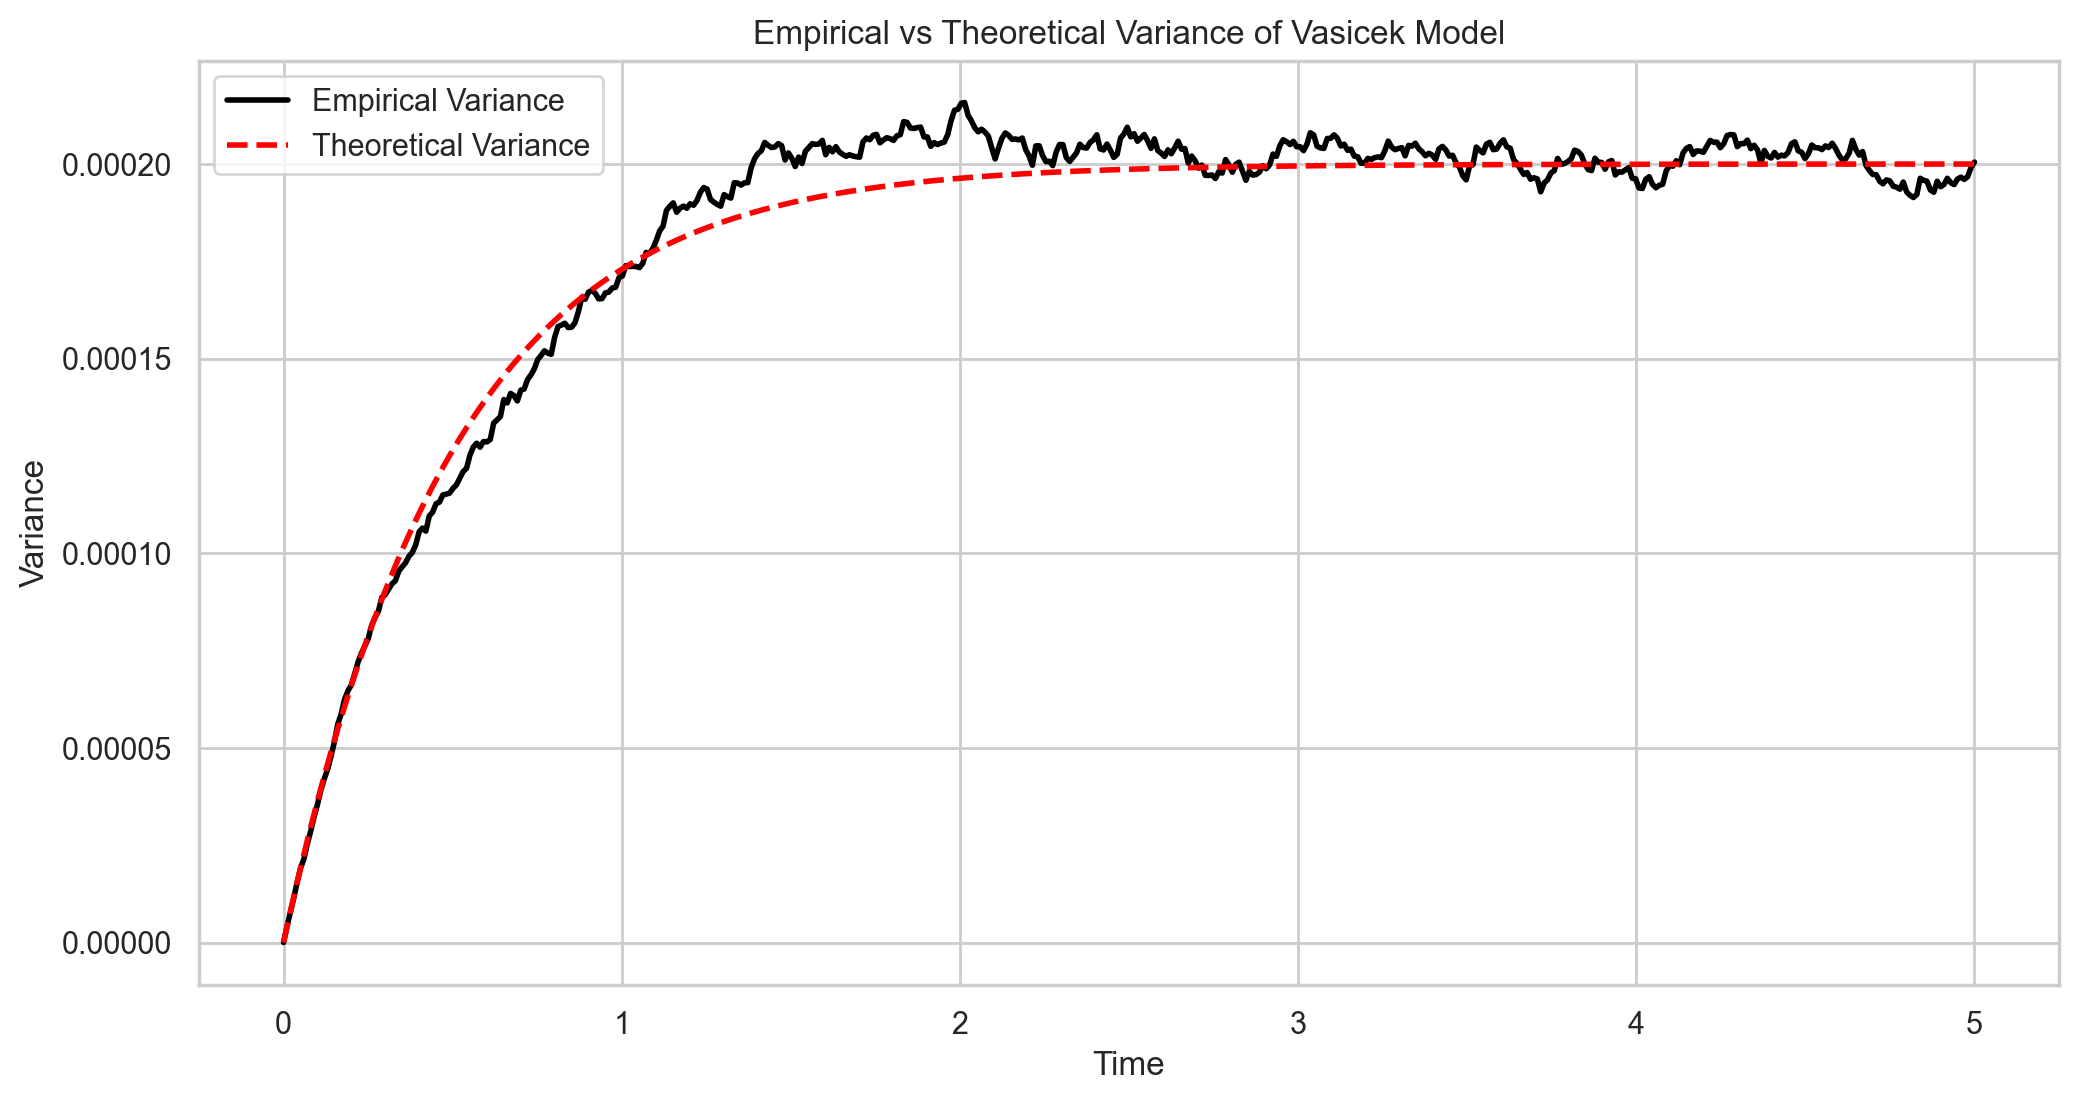

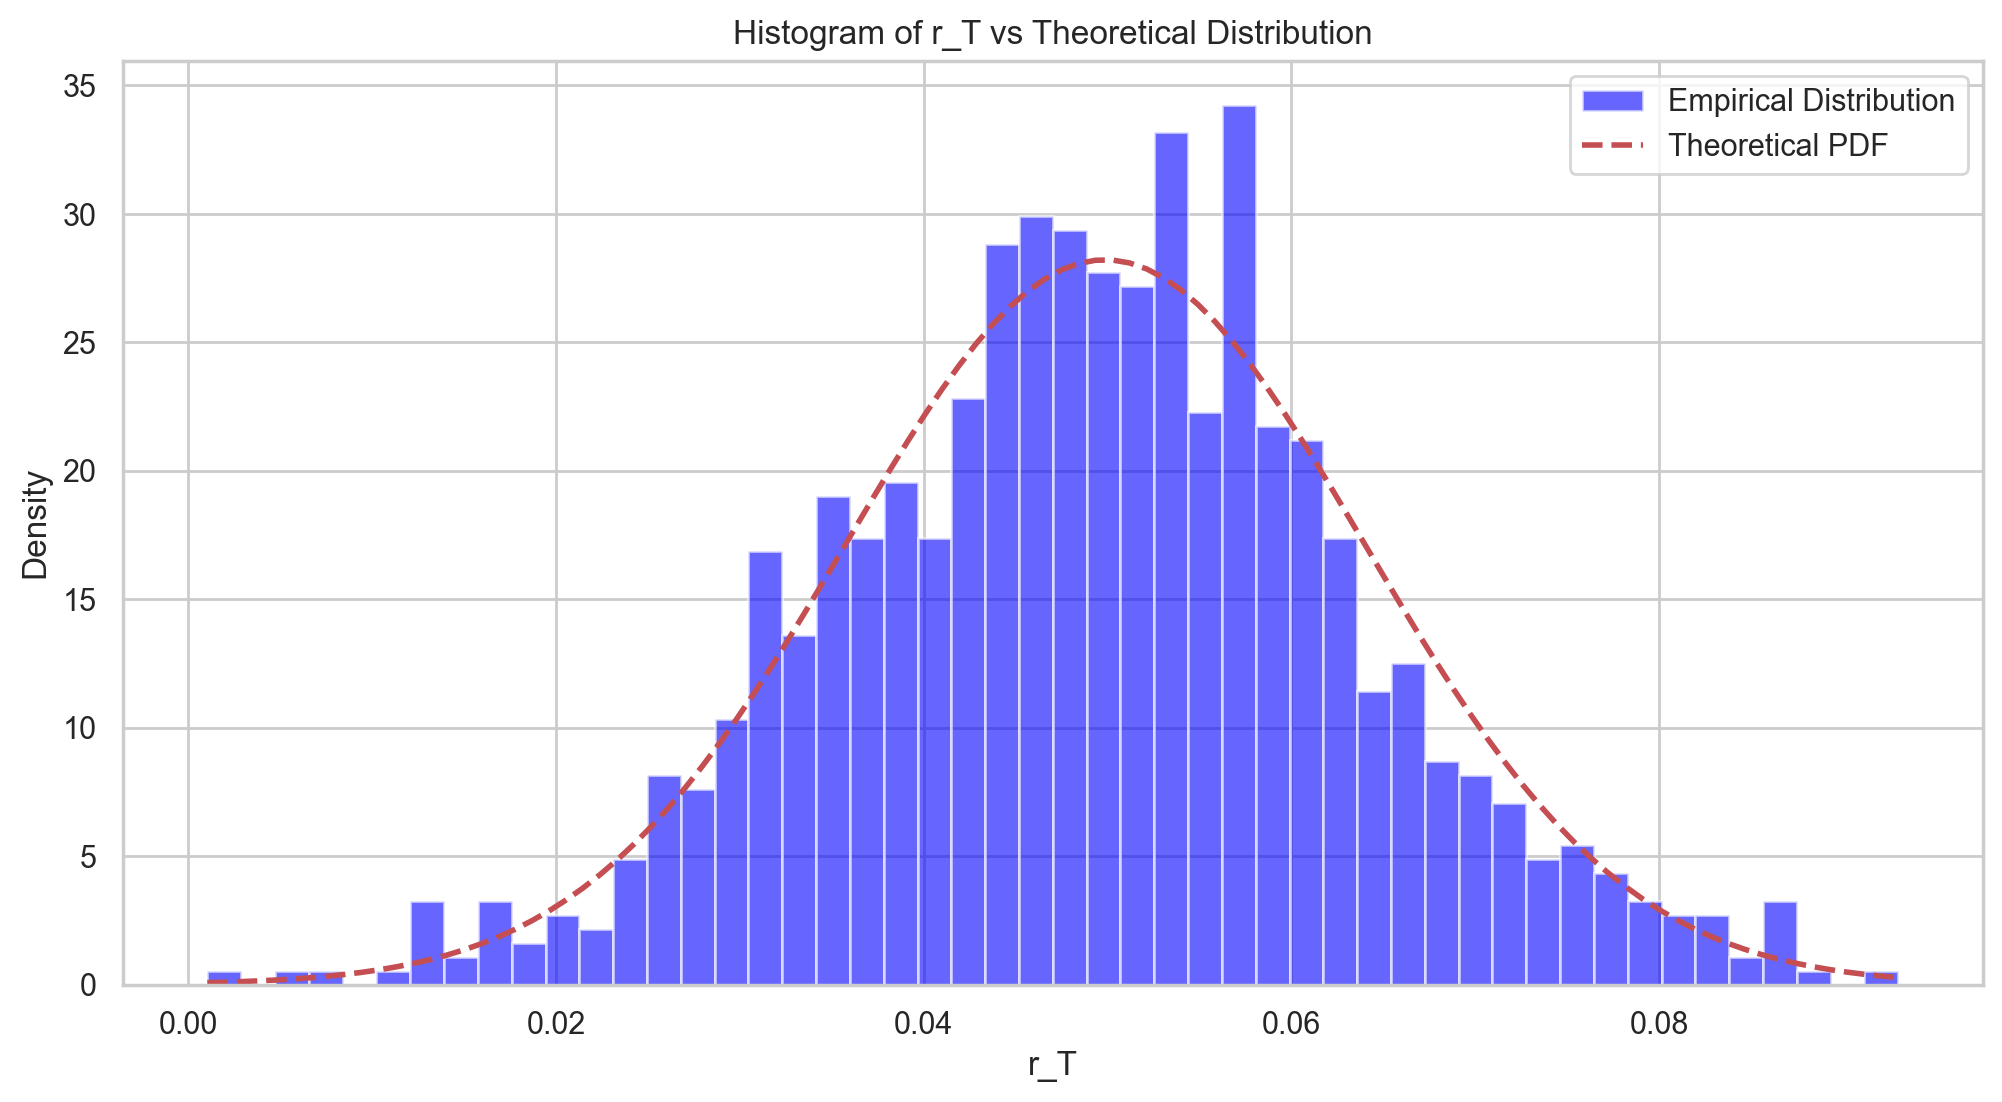

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters for the Vasicek Model
theta = 1.0   # Mean-reversion speed
mu = 0.05     # Long-term mean interest rate
sigma = 0.02  # Volatility
r0 = 0.03     # Initial interest rate
dt = 0.01     # Time step
T = 5.0       # Total time
N = int(T / dt)  # Number of time steps
M = 1000  # Number of Monte Carlo simulations

# Time array
t = np.linspace(0, T, N)

# Initialize interest rate array for all simulations
r = np.zeros((M, N))
r[:, 0] = r0

# Generate random noise for all simulations
dW = np.sqrt(dt) * np.random.randn(M, N)

# Euler-Maruyama method for solving the Vasicek SDE
for i in range(1, N):
    r[:, i] = r[:, i-1] + theta * (mu - r[:, i-1]) * dt + sigma * dW[:, i]

# Compute theoretical mean and variance
theoretical_mean = mu + (r0 - mu) * np.exp(-theta * t)
theoretical_variance = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))

theoretical_std = np.sqrt(theoretical_variance)
empirical_mean = np.mean(r, axis=0)
empirical_variance = np.var(r, axis=0)

# Plot the simulated paths
plt.figure(figsize=(12, 6))
for i in range(100):
    plt.plot(t, r[i, :], color='blue', alpha=0.1)
plt.plot(t, empirical_mean, color='black', linewidth=2, label="Empirical Mean")
plt.plot(t, theoretical_mean, color='red', linestyle='--', linewidth=2, label="Theoretical Mean")
plt.xlabel("Time")
plt.ylabel("Interest Rate")
plt.title("Monte Carlo Simulation of the Vasicek Model with Mean Trajectory")
plt.legend()
plt.show()

# Plot empirical vs theoretical variance
plt.figure(figsize=(12, 6))
plt.plot(t, empirical_variance, color='black', linewidth=2, label="Empirical Variance")
plt.plot(t, theoretical_variance, color='red', linestyle='--', linewidth=2, label="Theoretical Variance")
plt.xlabel("Time")
plt.ylabel("Variance")
plt.title("Empirical vs Theoretical Variance of Vasicek Model")
plt.legend()
plt.show()

# Histogram of r_T
r_T = r[:, -1]
plt.figure(figsize=(12, 6))
plt.hist(r_T, bins=50, density=True, alpha=0.6, color='blue', label="Empirical Distribution")
x_vals = np.linspace(min(r_T), max(r_T), 100)
plt.plot(x_vals, norm.pdf(x_vals, theoretical_mean[-1], theoretical_std[-1]), 'r--', linewidth=2, label="Theoretical PDF")
plt.xlabel("r_T")
plt.ylabel("Density")
plt.title("Histogram of r_T vs Theoretical Distribution")
plt.legend()
plt.show()
